# Import libraries

In [67]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import duckdb
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rcParams

# Custom osbad library
import osbad.modval as modval

rcParams["text.usetex"] = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Import dataset

* Import the ``cell_index`` from the training and test dataset.
* Purpose: to check if all cells have been evaluated.

## training cell_index

In [68]:
# Path to the DuckDB instance:
# "osbad/database/train_dataset_severson.db"
db_filepath = (
    Path.cwd()
    .parents[2]
    .joinpath("database","train_dataset_severson.db"))

# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all training dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_train_dataset_sv").fetchdf()

# Get the cell index of training dataset
unique_cell_index_train = df_duckdb["cell_index"].unique()
print(f"Unique cell index: {unique_cell_index_train}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Unique cell index: ['2017-05-12_5_4C-50per_3C_CH13' '2017-05-12_5_4C-50per_3C_CH14'
 '2017-05-12_5_4C-60per_3C_CH15' '2017-05-12_5_4C-60per_3C_CH16'
 '2017-05-12_5_4C-70per_3C_CH17' '2017-05-12_5_4C-70per_3C_CH18'
 '2017-05-12_6C-40per_3C_CH25' '2017-05-12_6C-40per_3C_CH26'
 '2017-05-12_6C-50per_3C_CH27' '2017-05-12_6C-50per_3C_CH28'
 '2017-05-12_6C-60per_3C_CH29' '2017-05-12_6C-60per_3C_CH30'
 '2017-05-12_7C-40per_3C_CH37' '2017-05-12_7C-40per_3C_CH38'
 '2017-05-12_4C-80per_4C_CH5' '2017-05-12_4C-80per_4C_CH6'
 '2017-05-12_4_4C-80per_4_4C_CH7' '2017-05-12_5_4C-80per_5_4C_CH11'
 '2017-05-12_5_4C-80per_5_4C_CH12' '2017-05-12_3_6C-80per_3_6C_CH1'
 '2017-05-12_3_6C-80per_3_6C_CH2' '2017-05-12_3_6C-80per_3_6C_CH3'
 '2017-05-12_5_4C-40per_3_6C_CH19']


## test cell_index

In [69]:
# Load only the test dataset
db_filepath = str(
    Path.cwd()
    .parents[2]
    .joinpath("database","test_dataset_severson.db"))

# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all test dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_test_dataset_sv").fetchdf()

# Get the cell index of test dataset
unique_cell_index_test = df_duckdb["cell_index"].unique()
print(f"Unique cell index: {unique_cell_index_test}")

Unique cell index: ['2017-05-12_5_4C-40per_3_6C_CH20' '2017-05-12_5_4C-50per_3_6C_CH21'
 '2017-05-12_5_4C-50per_3_6C_CH22' '2017-05-12_5_4C-60per_3_6C_CH23'
 '2017-05-12_5_4C-60per_3_6C_CH24' '2017-05-12_6C-30per_3_6C_CH31'
 '2017-05-12_6C-30per_3_6C_CH32' '2017-05-12_6C-40per_3_6C_CH33'
 '2017-05-12_6C-40per_3_6C_CH34' '2017-05-12_6C-50per_3_6C_CH35'
 '2017-05-12_6C-50per_3_6C_CH36' '2017-05-12_7C-30per_3_6C_CH39'
 '2017-05-12_7C-30per_3_6C_CH40' '2017-05-12_7C-40per_3_6C_CH41'
 '2017-05-12_7C-40per_3_6C_CH42' '2017-05-12_8C-15per_3_6C_CH43'
 '2017-05-12_8C-15per_3_6C_CH44' '2017-05-12_8C-25per_3_6C_CH45'
 '2017-05-12_8C-25per_3_6C_CH46' '2017-05-12_8C-35per_3_6C_CH47'
 '2017-05-12_8C-35per_3_6C_CH48' '2017-05-12_4_8C-80per_4_8C_CH9'
 '2017-05-12_4_8C-80per_4_8C_CH10']


## Define metrics filepath

In [70]:
# TRAIN_DATASET_METRICS_PATH = Path.cwd().joinpath(
#     "01_train_dataset",
#     "eval_metrics_hp_single_cell_severson.csv")

VALIDATE_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "02_validation_dataset",
    "eval_metrics_severson_train_multiple_cells.csv")

TEST_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "03_test_dataset",
    "eval_metrics_severson_test_multiple_cells.csv")


# 01: Train on a single cell

* The models are trained and evaluated on the dataset from a single cell
* While all models have perfect accuracy, precision, recall, F1-score and MCC score from the training and evaluation based on a single cell, it also implies that the models could be overfitted.
* Therefore, it is important to consider how the models perform across the dataset from multiple cells.

## Plot evaluation metrics for a single cell

In [ ]:
df_eval_metrics_train = pd.read_csv(TRAIN_DATASET_METRICS_PATH)

list_acc = df_eval_metrics_train["accuracy"].to_list()
list_precision = df_eval_metrics_train["precision"].to_list()
list_recall = df_eval_metrics_train["recall"].to_list()
list_f1 = df_eval_metrics_train["f1_score"].to_list()
list_mcc = df_eval_metrics_train["mcc_score"].to_list()

fig, ax = plt.subplots(figsize=(10,6))

bar_width = 0.15

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Train on a single cell (with hyperparameter tuning)",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_hp_single_cell.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# 02: Validation across multiple cells

For the **hyperparameter tuning using the transfer learning method**:

* In the validation stage, the hyperparameter tuning is performed across 23 different cell experimental dataset.
* The best trial parameters are recorded for each model across all cells.
* The hyperparameters are subsequently averaged and transfer to the test dataset (another 23 cells).
* The corresponding model metrics are also recorded and then averaged to evaluate how each model performs across 23 different cell dataset during the validation stage.

## Drop duplicates in the training dataset

* Some metrics have been evaluated multiple times for the same ``ml_model`` and ``cell_index``
* ``df_eval_metrics_validate`` ensures that the combined ``ml_model`` and ``cell_index`` are unique

In [71]:
df_eval_metrics_validate = pd.read_csv(VALIDATE_DATASET_METRICS_PATH)

df_eval_metrics_validate = df_eval_metrics_validate.drop_duplicates(
    subset=["ml_model", "cell_index"],
    keep="first")

## Check for missing ``cell_index``

* Check if any ``cell_index`` presents in the training dataset is missing in the evaluation dataset for all evaluated models.

In [72]:
unique_model_namelist = (
    df_eval_metrics_validate["ml_model"].unique())
print(f"Unique model name list: {unique_model_namelist}")

Unique model name list: ['iforest' 'knn' 'gmm' 'lof' 'pca' 'autoencoder']


In [73]:
total_cells_count_train = len(unique_cell_index_train)
print("Total cell count from the training dataset: " 
      + f"{total_cells_count_train}")

for selected_model_name in unique_model_namelist:

    df_selected_model = df_eval_metrics_validate[
        df_eval_metrics_validate["ml_model"] == selected_model_name]

    # -------------------------------------------------------------------------------
    # Get all unique cell index from the evaluation dataset
    training_eval_unique_cells = set(df_selected_model["cell_index"].unique())
    
    # cell_index that are in the training dataset, but not in the evaluation dataset
    diff_cell_index = set(unique_cell_index_train).difference(
        set(training_eval_unique_cells))
    
    # to check if all cells in the training cells have been evaluated for each model
    assert (len(diff_cell_index) == 0), (
        f"{selected_model_name} has missing cell index: {diff_cell_index}")

    # -------------------------------------------------------------------------------
    # To check that the number of evaluated cells also match the training dataset
    total_cells_count_eval = len(df_selected_model)

    assert (total_cells_count_eval == total_cells_count_train), (
        f"The number of evaluated cells does not match the training dataset")

Total cell count from the training dataset: 23


## Calculate average metrics

* Calculate the mean and the standard deviation of ``accuracy``, ``precision``, ``recall``, ``f1_score`` and ``mcc_score`` across all evaluated cells in the training dataset.
* The standard deviation describes how consistently each model performs from cell to cell, which the mean alone does not convey.

In [74]:
df_compare_metrics = modval.summarize_eval_metrics(
    df_eval_metrics=df_eval_metrics_validate)

In [75]:
df_compare_metrics.to_excel("eval_metrics_train_regression_proxy.xlsx")
df_compare_metrics

,ml_model,n_cells,avg_accuracy,std_accuracy,avg_precision,std_precision,avg_recall,std_recall,avg_f1_score,std_f1_score,avg_mcc_score,std_mcc_score
0,iforest,23,0.998295,0.002185,0.823775,0.218251,0.967391,0.156386,0.860387,0.177305,0.876415,0.152263
1,knn,23,0.999636,0.000979,0.958696,0.119328,0.989130,0.052129,0.968254,0.080083,0.970881,0.072197
2,gmm,23,0.988326,0.046320,0.868460,0.284810,0.867391,0.275767,0.791666,0.296946,0.819697,0.256917
3,lof,23,0.999322,0.001203,0.982609,0.057621,0.868841,0.263442,0.893444,0.196239,0.908152,0.166187
4,pca,23,0.999650,0.000969,0.967391,0.114424,0.980435,0.065260,0.968254,0.080083,0.970887,0.072190
5,autoencoder,23,0.999454,0.001173,0.967391,0.114424,0.942754,0.152490,0.941684,0.125843,0.947858,0.109202


## Plot evaluation metrics for all cells

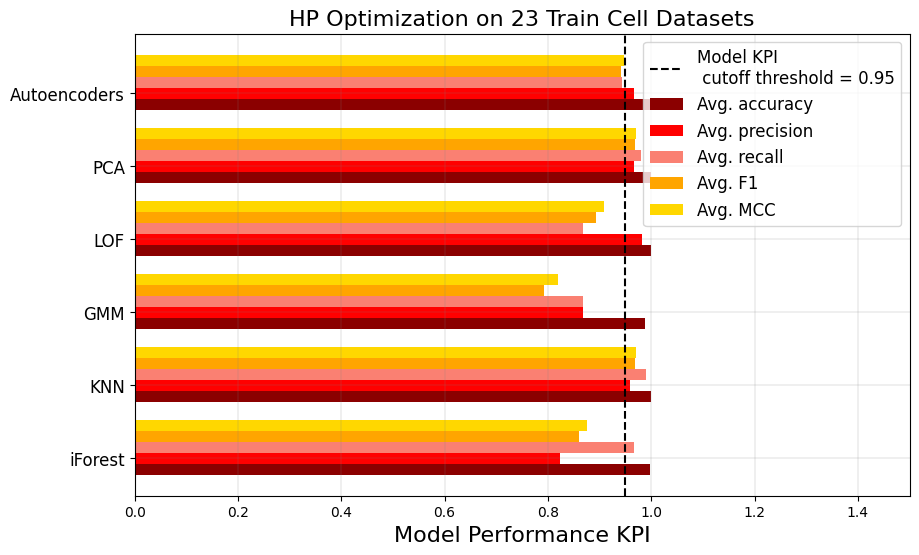

In [56]:
list_acc = df_compare_metrics["avg_accuracy"].to_list()
list_precision = df_compare_metrics["avg_precision"].to_list()
list_recall = df_compare_metrics["avg_recall"].to_list()
list_f1 = df_compare_metrics["avg_f1_score"].to_list()
list_mcc = df_compare_metrics["avg_mcc_score"].to_list()

bar_width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Avg. accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Avg. precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Avg. recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="Avg. F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="Avg. MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "HP Optimization on 23 Train Cell Datasets",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_with_hp_multiple_cells_regression_proxy.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# 03: Test across multiple cells

* No more hyperparameter tuning is performed during the test phase.
* The models are simply tested on the remaining 23 cells to evaluate how each model with the frozen hyperparameters generalize to new dataset.

## Drop duplicates in the test dataset

In [76]:
df_eval_metrics_test = pd.read_csv(TEST_DATASET_METRICS_PATH)

df_eval_metrics_test = df_eval_metrics_test.drop_duplicates(
    subset=["ml_model", "cell_index"],
    keep="first")
df_eval_metrics_test

,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,iforest,2017-05-12_5_4C-40per_3_6C_CH20,1.000000,1.000000,1.0,1.0,1.000000
1,iforest,2017-05-12_5_4C-50per_3_6C_CH21,1.000000,1.000000,1.0,1.0,1.000000
2,iforest,2017-05-12_5_4C-50per_3_6C_CH22,1.000000,1.000000,1.0,1.0,1.000000
3,iforest,2017-05-12_5_4C-60per_3_6C_CH23,1.000000,1.000000,1.0,1.0,1.000000
4,iforest,2017-05-12_5_4C-60per_3_6C_CH24,1.000000,1.000000,1.0,1.0,1.000000
...,...,...,...,...,...,...,...
133,autoencoder,2017-05-12_8C-25per_3_6C_CH46,1.000000,1.000000,1.0,1.0,1.000000
134,autoencoder,2017-05-12_8C-35per_3_6C_CH47,1.000000,1.000000,1.0,1.0,1.000000
135,autoencoder,2017-05-12_8C-35per_3_6C_CH48,1.000000,1.000000,1.0,1.0,1.000000
136,autoencoder,2017-05-12_4_8C-80per_4_8C_CH9,0.997704,0.333333,1.0,0.5,0.576686


## Check for missing ``cell_index``

In [77]:
unique_model_namelist = (
    df_eval_metrics_test["ml_model"].unique())
print(f"Unique model name list: {unique_model_namelist}")

Unique model name list: ['iforest' 'knn' 'gmm' 'lof' 'pca' 'autoencoder']


In [78]:
total_cells_count_test = len(unique_cell_index_test)
print("Total cell count from the testing dataset: " 
      + f"{total_cells_count_test}")

for selected_model_name in unique_model_namelist:
    print(f"Checking {selected_model_name}...")

    df_selected_model = df_eval_metrics_test[
        df_eval_metrics_test["ml_model"] == selected_model_name]

    # -------------------------------------------------------------------------------
    # Get all unique cell index from the evaluation dataset
    test_eval_unique_cells = set(df_selected_model["cell_index"].unique())
    
    # cell_index that are in the test dataset, but not in the evaluation dataset
    diff_cell_index = set(unique_cell_index_test).difference(
        set(test_eval_unique_cells))
    
    # to check if all cells in the testing cells have been evaluated for each model
    assert (len(diff_cell_index) == 0), (
        f"{selected_model_name} has missing cell index: {diff_cell_index}")

    # -------------------------------------------------------------------------------
    # To check that the number of evaluated cells also match the testing dataset
    total_cells_count_eval = len(df_selected_model)

    assert (total_cells_count_eval == total_cells_count_test), (
        f"The number of evaluated cells does not match the testing dataset")
    
print(f"All checks completed!")
print("*"*100)

Total cell count from the testing dataset: 23
Checking iforest...
Checking knn...
Checking gmm...
Checking lof...
Checking pca...
Checking autoencoder...
All checks completed!
****************************************************************************************************


## Calculate average metrics

* Calculate the mean and the standard deviation of each metric across all evaluated cells in the test dataset.

In [79]:
df_compare_metrics_test = modval.summarize_eval_metrics(
    df_eval_metrics=df_eval_metrics_test)

df_compare_metrics_test.to_excel("eval_metrics_test_regression_proxy.xlsx")
df_compare_metrics_test

,ml_model,n_cells,avg_accuracy,std_accuracy,avg_precision,std_precision,avg_recall,std_recall,avg_f1_score,std_f1_score,avg_mcc_score,std_mcc_score
0,iforest,23,0.998617,0.003621,0.880357,0.227634,0.989130,0.052129,0.908199,0.193408,0.917827,0.166778
1,knn,23,0.999661,0.000842,0.945652,0.167816,0.991304,0.041703,0.956660,0.129678,0.961900,0.109752
2,gmm,23,0.997883,0.001139,0.971014,0.139010,0.542029,0.255637,0.649689,0.190475,0.698792,0.158005
3,lof,23,0.999286,0.000877,0.935507,0.148928,0.897101,0.153548,0.901070,0.121564,0.908247,0.112261
4,pca,23,0.999793,0.000578,0.971014,0.139010,0.980435,0.065260,0.967219,0.108300,0.971132,0.092781
5,autoencoder,23,0.999744,0.000606,0.971014,0.139010,0.969565,0.080818,0.961008,0.110411,0.965286,0.095086


## Plot evaluation metrics

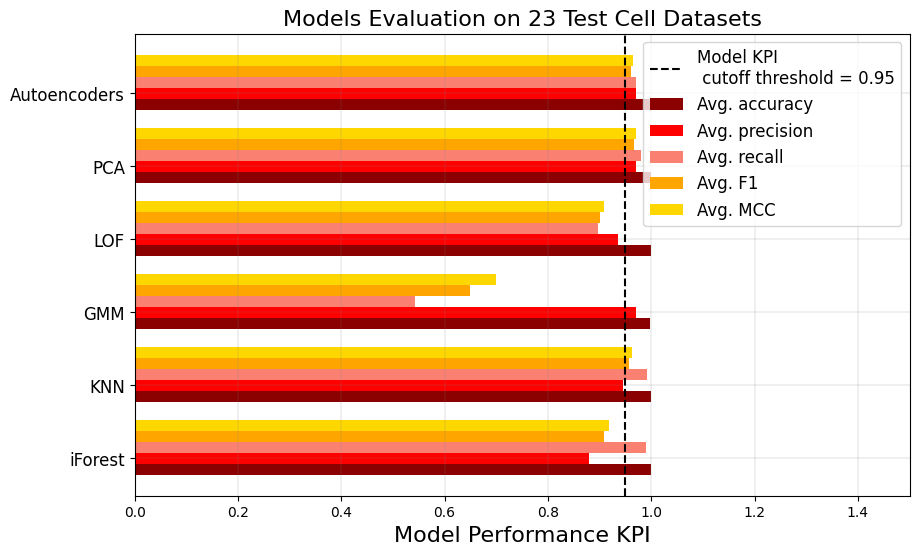

In [80]:
list_acc = df_compare_metrics_test["avg_accuracy"].to_list()
list_precision = df_compare_metrics_test["avg_precision"].to_list()
list_recall = df_compare_metrics_test["avg_recall"].to_list()
list_f1 = df_compare_metrics_test["avg_f1_score"].to_list()
list_mcc = df_compare_metrics_test["avg_mcc_score"].to_list()

bar_width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Avg. accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Avg. precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Avg. recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="Avg. F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="Avg. MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Models Evaluation on 23 Test Cell Datasets",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_test_regression_proxy.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()